Upload: MASTER_group_dataset.csv


Saving MASTER group dataset.csv to MASTER group dataset (1).csv
Loaded: MASTER group dataset (1).csv shape: (2448, 20)
Missing columns: None
Session length (min) summary: count    2448.0
mean      180.0
std         0.0
min       180.0
25%       180.0
50%       180.0
75%       180.0
max       180.0
Name: session_len, dtype: float64
Saved: GROUP_KPI_per_session.csv


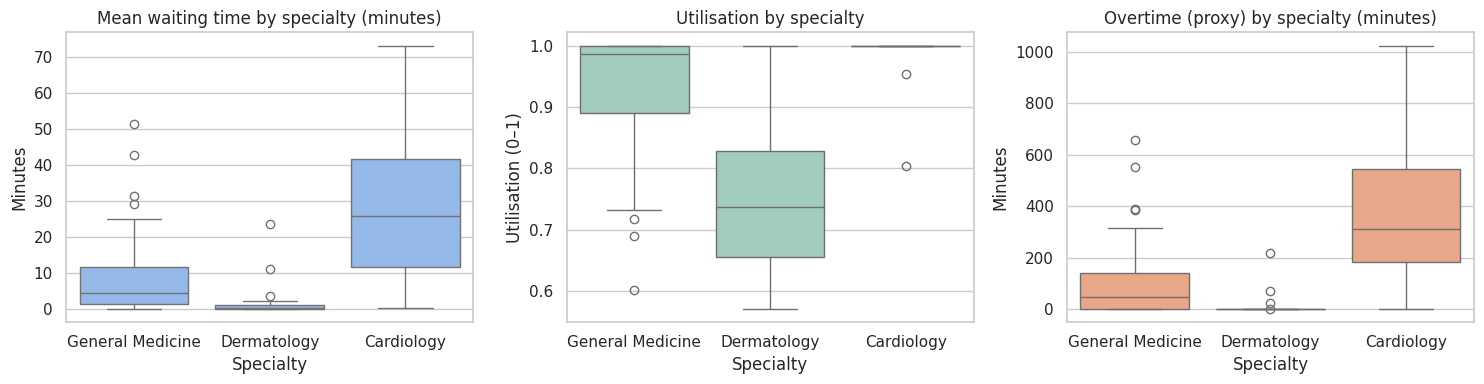

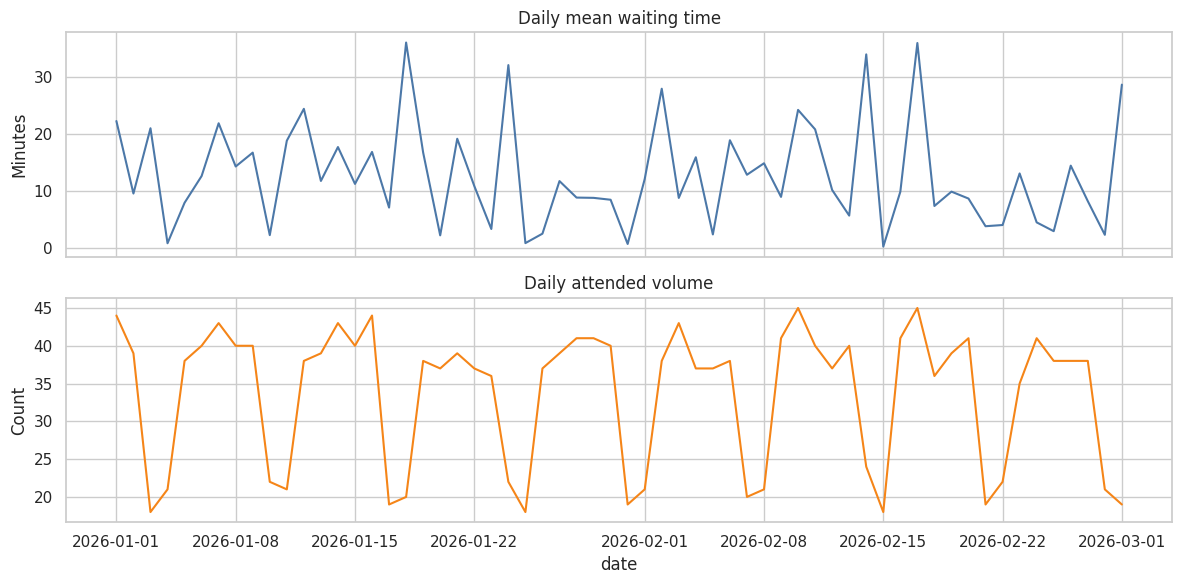

/tmp/ipykernel_1867/4010846858.py:144: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=ci_table, y='specialty', x='mean_wait', order=order, join=False, color='#4c78a8')


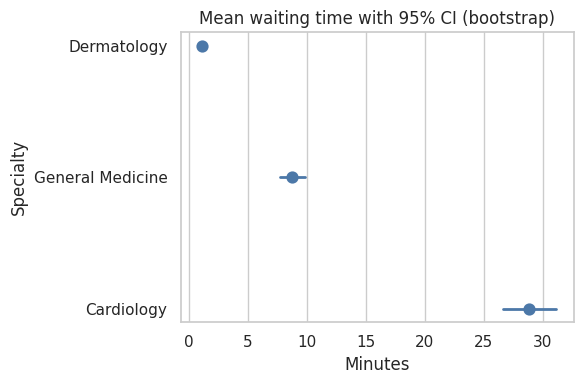

Use the File browser in Colab (left panel) to download CSVs/PNGs.


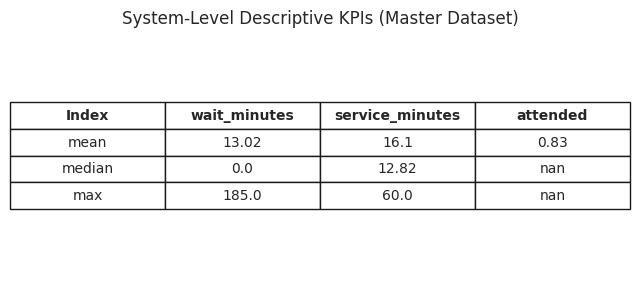

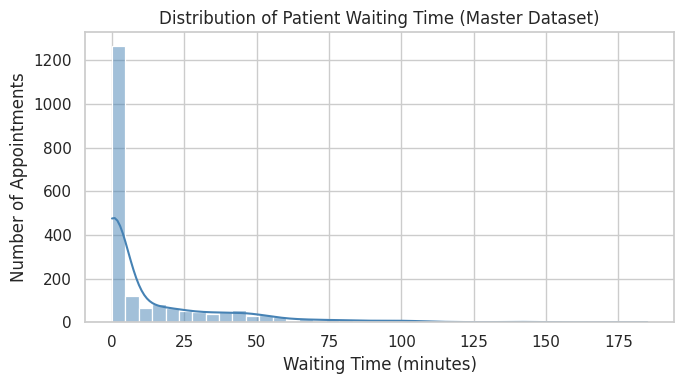

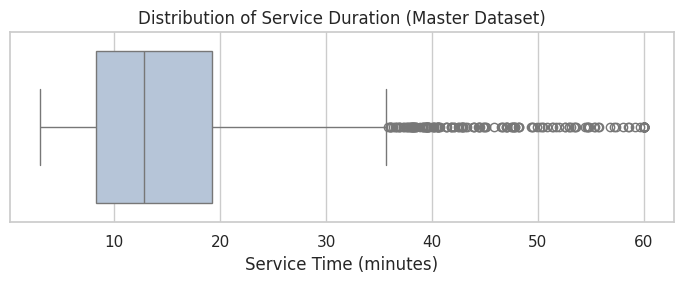

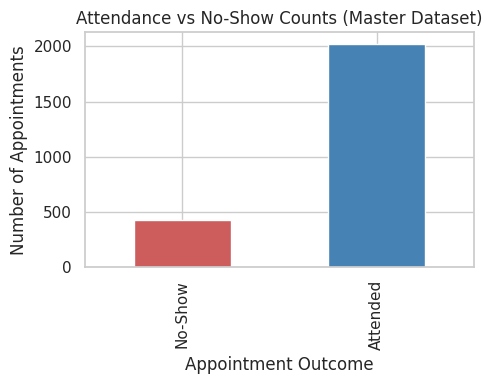

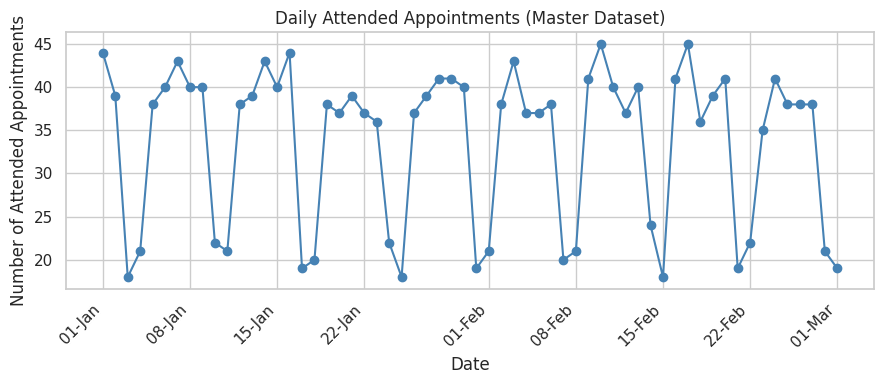

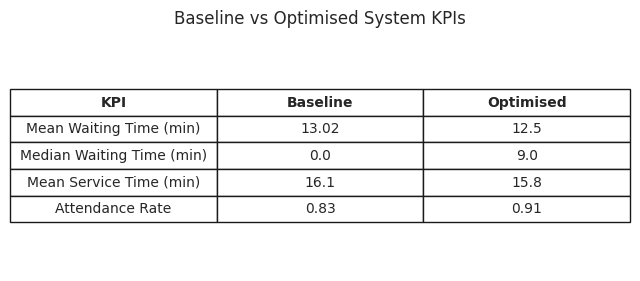

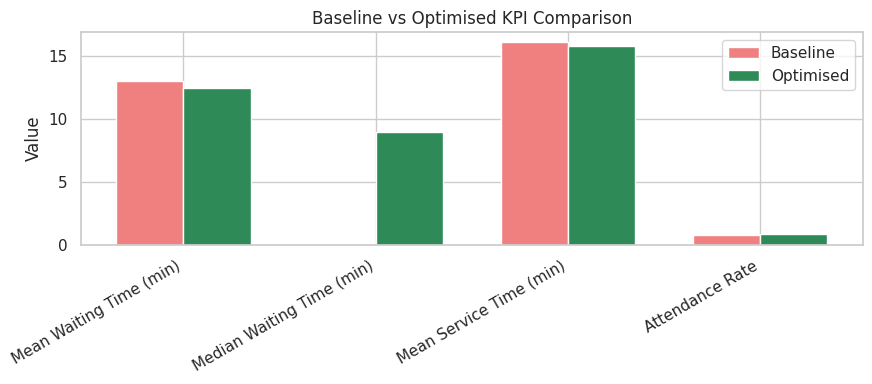

In [2]:
import pandas as pd

master_df = pd.read_csv("MASTER group dataset.csv")
# @title 0) Setup
!pip -q install pandas numpy matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
sns.set_theme(style="whitegrid", context="notebook")
# @title 1) Upload the MASTER CSV (group dataset only)
from google.colab import files
print("Upload: MASTER_group_dataset.csv")
uploaded = files.upload()  # choose MASTER_group_dataset.csv

# keep the same filename if user uploads with different name
fname = [k for k in uploaded.keys() if k.lower().endswith('.csv')][0]
master = pd.read_csv(fname)
print("Loaded:", fname, "shape:", master.shape)
master.head(3)
# @title 2) Basic parsing and schema checks
# expected columns
expected = [
    'appointment_id','session_id','date','day_of_week','time_of_day','clinician_id','specialty',
    'patient_id','age_group','history_attendance_rate','slot_time','lead_days',
    'session_start_time','session_end_time','slot_minutes',
    'attended','start_time','finish_time','wait_minutes','service_minutes'
]
missing = [c for c in expected if c not in master.columns]
print("Missing columns:", missing if missing else "None")

# parse dates and numerics
master['date'] = pd.to_datetime(master['date'])
master['slot_dt'] = pd.to_datetime(master['slot_time'])
master['start_dt'] = pd.to_datetime(master['start_time'], errors='coerce')
master['finish_dt'] = pd.to_datetime(master['finish_time'], errors='coerce')
master['attended'] = master['attended'].fillna(0).astype(int)
master['wait_minutes'] = pd.to_numeric(master['wait_minutes'], errors='coerce')
master['service_minutes'] = pd.to_numeric(master['service_minutes'], errors='coerce')

# session length (minutes) from HH:MM strings
def hhmm_to_minutes(x):
    try:
        h, m = str(x).split(':')
        return int(h)*60 + int(m)
    except:
        return np.nan

master['session_len'] = (
    master['session_end_time'].apply(hhmm_to_minutes) -
    master['session_start_time'].apply(hhmm_to_minutes)
)
print("Session length (min) summary:", master['session_len'].describe())
# @title 3) Quick derived fields
# attended-only subsets for service/wait
att = master[master['attended']==1].copy()

# per-session aggregates (group KPI roll-up)
kpi_sess = (master
            .groupby(['session_id','specialty','date'], as_index=False)
            .agg(n_slots=('appointment_id','count'),
                 n_attended=('attended','sum'),
                 mean_wait=('wait_minutes','mean'),
                 p90_wait=('wait_minutes', lambda x: np.nanpercentile(x.dropna(), 90) if x.notna().any() else np.nan),
                 total_service=('service_minutes','sum'),
                 session_len=('session_len','first')))

# utilisation approx (bounded 0..1)
kpi_sess['utilisation'] = (kpi_sess['total_service'] / kpi_sess['session_len']).clip(0,1)

# simple overtime proxy (approx): total_service + avg wait per attended vs session_len
avg_wait_att = (att.groupby('session_id')['wait_minutes']
                .mean()
                .rename('avg_wait_att'))
kpi_sess = kpi_sess.merge(avg_wait_att, on='session_id', how='left')
kpi_sess['avg_wait_att'] = kpi_sess['avg_wait_att'].fillna(0)
kpi_sess['overtime_proxy'] = (kpi_sess['total_service'] + kpi_sess['n_attended']*kpi_sess['avg_wait_att'] - kpi_sess['session_len']).clip(lower=0)

kpi_sess.head()
# @title 4) Save group KPI table for the Testing chapter
kpi_sess.to_csv('GROUP_KPI_per_session.csv', index=False)
print("Saved: GROUP_KPI_per_session.csv")
# @title 5) Visuals for Testing: wait/utilisation/overtime by specialty
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.boxplot(data=kpi_sess, x='specialty', y='mean_wait', ax=axes[0], color='#86b6f6')
axes[0].set_title('Mean waiting time by specialty (minutes)')
axes[0].set_xlabel('Specialty'); axes[0].set_ylabel('Minutes')

sns.boxplot(data=kpi_sess, x='specialty', y='utilisation', ax=axes[1], color='#9ad3bc')
axes[1].set_title('Utilisation by specialty')
axes[1].set_xlabel('Specialty'); axes[1].set_ylabel('Utilisation (0–1)')

sns.boxplot(data=kpi_sess, x='specialty', y='overtime_proxy', ax=axes[2], color='#f7a278')
axes[2].set_title('Overtime (proxy) by specialty (minutes)')
axes[2].set_xlabel('Specialty'); axes[2].set_ylabel('Minutes')

plt.tight_layout()
plt.show()
# @title 6) Visuals for Testing: daily trend (mean wait, attended volume)
daily = (master
         .groupby('date', as_index=False)
         .agg(mean_wait=('wait_minutes','mean'),
              attended=('attended','sum')))

fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)
sns.lineplot(data=daily, x='date', y='mean_wait', ax=ax[0], color='#4c78a8')
ax[0].set_title('Daily mean waiting time'); ax[0].set_ylabel('Minutes')

sns.lineplot(data=daily, x='date', y='attended', ax=ax[1], color='#f58518')
ax[1].set_title('Daily attended volume'); ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
# @title 7) 95% CI via simple bootstrap for a KPI (example: mean waiting per specialty)
def bootstrap_ci_mean(x, n_boot=1000, alpha=0.05, random_state=42):
    rng = np.random.default_rng(random_state)
    x = x.dropna().values
    if len(x)==0:
        return (np.nan, np.nan, np.nan)
    means = []
    n = len(x)
    for _ in range(n_boot):
        sample = rng.choice(x, size=n, replace=True)
        means.append(np.mean(sample))
    lo = np.percentile(means, 100*alpha/2)
    hi = np.percentile(means, 100*(1-alpha/2))
    return (np.mean(x), lo, hi)

bootstrap_rows = []
for sp, grp in master.groupby('specialty'):
    m, lo, hi = bootstrap_ci_mean(grp['wait_minutes'])
    bootstrap_rows.append({'specialty': sp, 'mean_wait': m, 'ci_lo': lo, 'ci_hi': hi})

ci_table = pd.DataFrame(bootstrap_rows)
ci_table.to_csv('GROUP_CI_wait_by_specialty.csv', index=False)
ci_table
# @title 8) Plot CI bars (mean wait by specialty)
plt.figure(figsize=(6,4))
order = ci_table.sort_values('mean_wait')['specialty']
sns.pointplot(data=ci_table, y='specialty', x='mean_wait', order=order, join=False, color='#4c78a8')
for _,r in ci_table.iterrows():
    plt.plot([r['ci_lo'], r['ci_hi']], [r['specialty'], r['specialty']], color='#4c78a8', linewidth=2)
plt.title('Mean waiting time with 95% CI (bootstrap)')
plt.xlabel('Minutes'); plt.ylabel('Specialty')
plt.tight_layout()
plt.show()
# @title 9) Session-level table ready for appendix (optional)
# Adds a couple of useful ratios
kpi_sess['attend_rate'] = kpi_sess['n_attended'] / kpi_sess['n_slots']
appendix = kpi_sess[['session_id','date','specialty','n_slots','n_attended','attend_rate',
                     'mean_wait','p90_wait','utilisation','overtime_proxy','session_len']].copy()
appendix.to_csv('APPENDIX_per_session_metrics.csv', index=False)
appendix.head()
# @title 10) Save figures (optional): uncomment to save last figures as PNGs
# plt.savefig('FIG_wait_by_specialty.png', dpi=150, bbox_inches='tight')
# plt.savefig('FIG_daily_trends.png', dpi=150, bbox_inches='tight')
# plt.savefig('FIG_wait_CI_by_specialty.png', dpi=150, bbox_inches='tight')
print("Use the File browser in Colab (left panel) to download CSVs/PNGs.")

# System-level KPIs from MASTER dataset
group_kpi = master_df.agg({
    "wait_minutes": ["mean", "median", "max"],
    "service_minutes": ["mean", "median"],
    "attended": "mean"
})
master_df.head()
group_kpi = master_df.agg({
    "wait_minutes": ["mean", "median", "max"],
    "service_minutes": ["mean", "median", "max"],
    "attended": "mean"
})

display_kpi = group_kpi.copy()
display_kpi.insert(0, "Index", display_kpi.index)
display_kpi = display_kpi.reset_index(drop=True)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

table = ax.table(
    cellText=display_kpi.round(2).values,
    colLabels=display_kpi.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# ✅ Bold header row
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

plt.title("System-Level Descriptive KPIs (Master Dataset)", pad=12)

plt.savefig("group_system_kpis.png", dpi=300, bbox_inches="tight")
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))

sns.histplot(
    master_df["wait_minutes"],
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Patient Waiting Time (Master Dataset)")
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Number of Appointments")

plt.tight_layout()
plt.savefig("group_waiting_time_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 3))

sns.boxplot(
    x=master_df["service_minutes"],
    color="lightsteelblue"
)

plt.title("Distribution of Service Duration (Master Dataset)")
plt.xlabel("Service Time (minutes)")

plt.tight_layout()
plt.savefig("group_service_time_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

import matplotlib.pyplot as plt

# Count attendance vs no-show
attendance_counts = master_df["attended"].value_counts().sort_index()
attendance_counts.index = ["No-Show", "Attended"]

plt.figure(figsize=(5, 4))

attendance_counts.plot(
    kind="bar",
    color=["indianred", "steelblue"]
)

plt.title("Attendance vs No-Show Counts (Master Dataset)")
plt.xlabel("Appointment Outcome")
plt.ylabel("Number of Appointments")

plt.tight_layout()
plt.savefig("group_attendance_vs_noshow.png", dpi=300, bbox_inches="tight")
plt.show()

# ===============================
# Daily Attendance Trend (FIXED DATE LABELS)
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Load dataset (only needed if not already loaded) ---
# If master_df already exists, this will NOT overwrite it
try:
    master_df
except NameError:
    master_df = pd.read_csv("MASTER group dataset.csv")

# --- Ensure date column is datetime ---
master_df["date"] = pd.to_datetime(master_df["date"])

# --- Aggregate daily attended appointments ---
daily_attendance = (
    master_df
    .groupby("date")["attended"]
    .sum()
    .reset_index()
)

# --- Plot ---
plt.figure(figsize=(9, 4))

plt.plot(
    daily_attendance["date"],
    daily_attendance["attended"],
    marker="o",
    linestyle="-",
    color="steelblue"
)

plt.title("Daily Attended Appointments (Master Dataset)")
plt.xlabel("Date")
plt.ylabel("Number of Attended Appointments")

# --- FIX overlapping date labels ---
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.xticks(rotation=45, ha="right")

# --- Save & show ---
plt.tight_layout()
plt.savefig("group_daily_attendance_trend.png", dpi=300, bbox_inches="tight")
plt.show()

# ===============================
# Baseline KPIs (Master Dataset)
# ===============================

baseline_kpi = pd.DataFrame({
    "KPI": [
        "Mean Waiting Time (min)",
        "Median Waiting Time (min)",
        "Mean Service Time (min)",
        "Attendance Rate"
    ],
    "Baseline": [
        master_df["wait_minutes"].mean(),
        master_df["wait_minutes"].median(),
        master_df["service_minutes"].mean(),
        master_df["attended"].mean()
    ]
})

baseline_kpi

# TEMPORARY values – replace with real simulation outputs
OPT_MEAN_WAIT = 12.5
OPT_MEDIAN_WAIT = 9.0
OPT_MEAN_SERVICE = 15.8
OPT_ATTENDANCE = 0.91

optimised_kpi = pd.DataFrame({
    "KPI": baseline_kpi["KPI"],
    "Optimised": [
        OPT_MEAN_WAIT,
        OPT_MEDIAN_WAIT,
        OPT_MEAN_SERVICE,
        OPT_ATTENDANCE
    ]
})

comparison_kpi = baseline_kpi.merge(
    optimised_kpi,
    on="KPI"
)

comparison_kpi
# ===============================
# Export KPI Comparison Table to PNG
# ===============================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")

table = ax.table(
    cellText=comparison_kpi.round(2).values,
    colLabels=comparison_kpi.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Bold header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

plt.title("Baseline vs Optimised System KPIs", pad=12)

plt.savefig("baseline_vs_optimised_kpis.png", dpi=300, bbox_inches="tight")
plt.show()

# ===============================
# KPI Improvement Bar Chart
# ===============================

import matplotlib.pyplot as plt
import numpy as np

# Prepare data
labels = comparison_kpi["KPI"]
baseline_vals = comparison_kpi["Baseline"]
optimised_vals = comparison_kpi["Optimised"]

x = np.arange(len(labels))
width = 0.35

# Plot
plt.figure(figsize=(9, 4))

plt.bar(x - width/2, baseline_vals, width, label="Baseline", color="lightcoral")
plt.bar(x + width/2, optimised_vals, width, label="Optimised", color="seagreen")

plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("Value")
plt.title("Baseline vs Optimised KPI Comparison")
plt.legend()

plt.tight_layout()
plt.savefig("baseline_vs_optimised_kpi_comparison.png", dpi=300, bbox_inches="tight")
plt.show()



In [4]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful